# Hierarchical IMSTE quality and runtime

Compare exact IMSTE with hierarchical IMSTE on a stratified 10,000-image sample of real MNIST. The benchmark reports graph overlap, embedding quality, and paired runtime differences across the configured seeds.


In [1]:
import sys
from pathlib import Path
from IPython.display import display

repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'mst_embedding').is_dir()),
    None,
)
if repo_root is not None:
    for path in (repo_root, repo_root / 'notebooks'):
        if str(path) not in sys.path:
            sys.path.insert(0, str(path))

from hierarchical_quality_utils import run_mnist_quality_benchmark

# MNIST sample and paired trial settings.
DATA_SEED = 42
SEEDS = tuple(range(1,3))
MAX_SAMPLES = 2_000
N_MSTS = 8
N_EPOCHS = 500
N_CLUSTERS_TO_TRY = [10, 30, 60, 90]
N_COARSE_MSTS = 3
N_LOCAL_MSTS = 3
MINIBATCH_SIZE = 256
N_JOBS = -1
DEVICE = 'cpu'

results = run_mnist_quality_benchmark(
    seeds=SEEDS,
    max_samples=MAX_SAMPLES,
    data_seed=DATA_SEED,
    n_msts=N_MSTS,
    n_epochs=N_EPOCHS,
    n_clusters_to_try=N_CLUSTERS_TO_TRY,
    n_coarse_msts=N_COARSE_MSTS,
    n_local_msts=N_LOCAL_MSTS,
    minibatch_size=MINIBATCH_SIZE,
    n_jobs=N_JOBS,
    device=DEVICE,
)

display(results['runs'])
display(results['summary'])
if not results['failures'].empty:
    display(results['failures'])


Fixed MNIST benchmark data: 2,000 samples × 784 features; seeds=(1, 2)
Completed 10 of 10 trials; 0 failed.


,mode,seed,n_clusters,unique_edges,exact_edge_precision,exact_edge_recall,trustworthiness,5NN_accuracy,delta_trustworthiness,delta_5NN_accuracy,delta_fit_time_seconds,graph_construction_seconds,embedding_optimization_seconds,fit_time_seconds,wall_time_seconds
0,exact,1,NaN,15992,NaN,NaN,0.877086,0.8110,NaN,NaN,NaN,0.674983,2.767881,3.443680,3.443710
1,hierarchical,1,10.0,7996,0.933967,0.466983,0.838414,0.7415,-0.038672,-0.0695,-1.902106,0.318621,1.222493,1.541574,1.541593
2,hierarchical,1,30.0,8694,0.894640,0.486368,0.836388,0.6925,-0.040698,-0.1185,-1.818609,0.272865,1.351743,1.625071,1.625089
3,hierarchical,1,60.0,9189,0.844379,0.485180,0.847262,0.7015,-0.029823,-0.1095,-1.640047,0.238537,1.564662,1.803633,1.803650
4,hierarchical,1,90.0,9403,0.837924,0.492684,0.849101,0.7540,-0.027985,-0.0570,-1.726544,0.232871,1.483819,1.717136,1.717155
5,exact,2,NaN,15992,NaN,NaN,0.875226,0.8135,NaN,NaN,NaN,0.667962,2.365222,3.033631,3.033646
6,hierarchical,2,10.0,8062,0.943562,0.475675,0.843142,0.7440,-0.032084,-0.0695,-1.519311,0.328587,1.185302,1.514320,1.514337
7,hierarchical,2,30.0,8369,0.912176,0.477364,0.828797,0.7270,-0.046428,-0.0865,-1.451311,0.241381,1.340502,1.582321,1.582337
8,hierarchical,2,60.0,8705,0.883056,0.480678,0.851173,0.7200,-0.024053,-0.0935,-1.461672,0.219607,1.351906,1.571960,1.571976
9,hierarchical,2,90.0,9566,0.843090,0.504315,0.859548,0.7280,-0.015677,-0.0855,-1.348658,0.237027,1.447512,1.684974,1.684991


,mode,n_clusters,successful_runs,unique_edges_median,unique_edges_q25,unique_edges_q75,trustworthiness_median,trustworthiness_q25,trustworthiness_q75,5NN_accuracy_median,...,exact_edge_recall_q75,delta_trustworthiness_median,delta_trustworthiness_q25,delta_trustworthiness_q75,delta_5NN_accuracy_median,delta_5NN_accuracy_q25,delta_5NN_accuracy_q75,delta_fit_time_seconds_median,delta_fit_time_seconds_q25,delta_fit_time_seconds_q75
0,exact,NaN,2,15992.0,15992.00,15992.00,0.876156,0.875691,0.876621,0.81225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,hierarchical,10.0,2,8029.0,8012.50,8045.50,0.840778,0.839596,0.841960,0.74275,...,0.473502,-0.035378,-0.037025,-0.033731,-0.06950,-0.069500,-0.069500,-1.710708,-1.806407,-1.615010
2,hierarchical,30.0,2,8531.5,8450.25,8612.75,0.832593,0.830695,0.834490,0.70975,...,0.484117,-0.043563,-0.044996,-0.042131,-0.10250,-0.110500,-0.094500,-1.634960,-1.726785,-1.543135
3,hierarchical,60.0,2,8947.0,8826.00,9068.00,0.849218,0.848240,0.850195,0.71075,...,0.484055,-0.026938,-0.028381,-0.025495,-0.10150,-0.105500,-0.097500,-1.550859,-1.595453,-1.506266
4,hierarchical,90.0,2,9484.5,9443.75,9525.25,0.854325,0.851713,0.856936,0.74100,...,0.501407,-0.021831,-0.024908,-0.018754,-0.07125,-0.078375,-0.064125,-1.537601,-1.632073,-1.443129


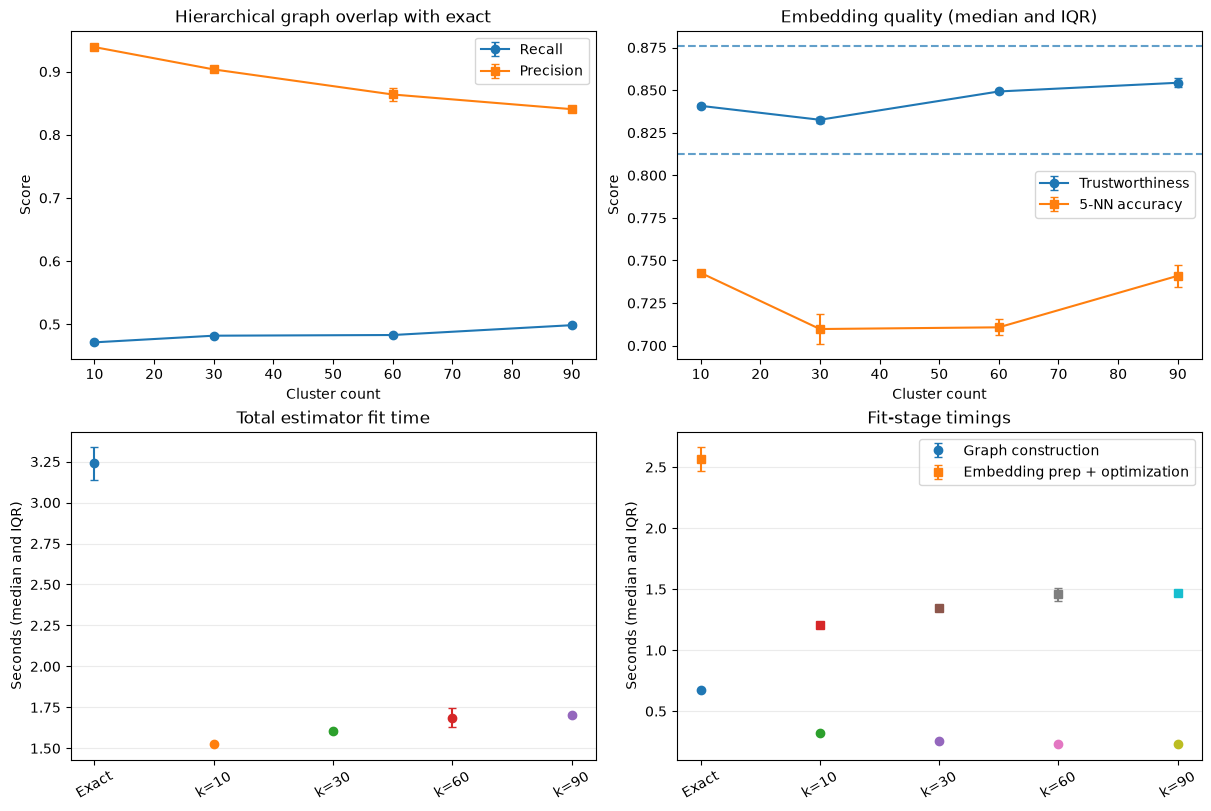

,n_clusters,successful_runs,delta_trustworthiness_median,delta_trustworthiness_q25,delta_trustworthiness_q75,delta_5NN_accuracy_median,delta_5NN_accuracy_q25,delta_5NN_accuracy_q75,delta_fit_time_seconds_median,delta_fit_time_seconds_q25,delta_fit_time_seconds_q75
1,10.0,2,-0.035378,-0.037025,-0.033731,-0.06950,-0.069500,-0.069500,-1.710708,-1.806407,-1.615010
2,30.0,2,-0.043563,-0.044996,-0.042131,-0.10250,-0.110500,-0.094500,-1.634960,-1.726785,-1.543135
3,60.0,2,-0.026938,-0.028381,-0.025495,-0.10150,-0.105500,-0.097500,-1.550859,-1.595453,-1.506266
4,90.0,2,-0.021831,-0.024908,-0.018754,-0.07125,-0.078375,-0.064125,-1.537601,-1.632073,-1.443129


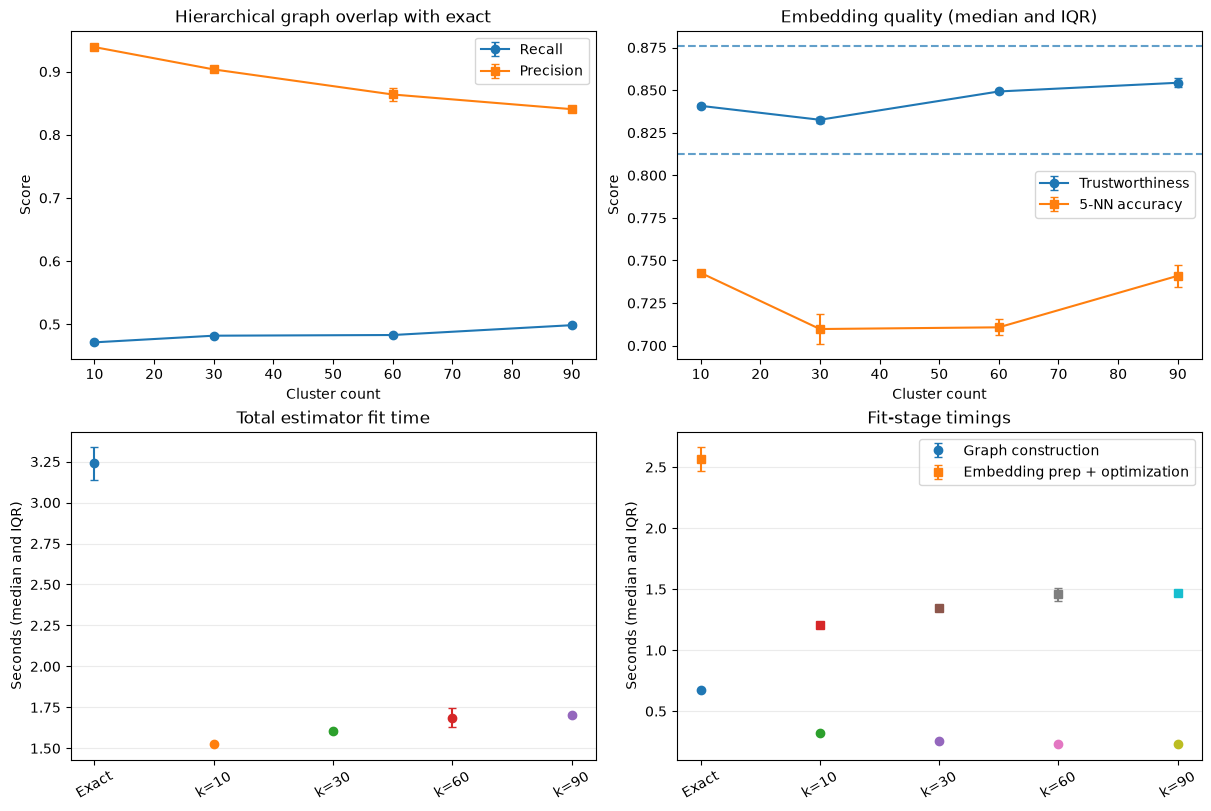

In [2]:
from hierarchical_quality_utils import plot_quality_results

fig, paired_deltas = plot_quality_results(results['summary'])
display(fig)
display(paired_deltas)
